## ROC - AUC Score
Checks correct threshord to classify

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification

X,y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=42
)
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274
1,-0.916511,-0.566395,-1.008614,0.831617,-1.176962,1.820544,1.752375,-0.984534,0.363896,0.209470
2,-0.109484,-0.432774,-0.457649,0.793818,-0.268646,-1.836360,1.239086,-0.246383,-1.058145,-0.297376
3,1.750412,2.023606,1.688159,0.006800,-1.607661,0.184741,-2.619427,-0.357445,-1.473127,-0.190039
4,-0.224726,-0.711303,-0.220778,0.117124,1.536061,0.597538,0.348645,-0.939156,0.175915,0.236224
...,...,...,...,...,...,...,...,...,...,...
995,-1.367638,1.462255,-1.154918,-0.290454,-0.413424,0.032396,1.545490,1.428760,1.687092,1.072542
996,-1.514876,-3.221016,-1.300744,0.395599,-0.527994,1.353069,1.777506,-1.680870,1.798510,0.034272
997,1.674633,1.754933,1.586154,0.018402,-1.514470,0.321593,-2.417694,0.692723,-1.503850,0.225264
998,-0.778609,-0.835689,-0.194842,1.097220,0.180071,-0.272933,-0.533188,-0.497354,2.472138,0.867187


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

### Build Dummy Data
Create a naive baseline that always predicts probability = 0 for every test point, regardless of input (worst case)

In [3]:
dummy_probs = [0 for _ in range(len(y_test))]

In [5]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
model_probs = model.predict_proba(X_test)[:, 1]   # take only the positive-class column
print(model_probs)

[0.22552209 0.9663315  0.32931785 0.9201332  0.02338335 0.95864272
 0.02097123 0.04063274 0.19147995 0.31504568 0.08633055 0.73640298
 0.47415581 0.78808765 0.20640794 0.05337832 0.97370421 0.67578738
 0.68519642 0.79504378 0.49541293 0.03329637 0.7994852  0.22210809
 0.12701368 0.95980093 0.07878148 0.18569764 0.51567604 0.65402099
 0.93174827 0.99945985 0.03067024 0.02709057 0.0576305  0.48069918
 0.9153521  0.67403106 0.52311681 0.99984621 0.08412092 0.91350916
 0.52047111 0.06431862 0.02210708 0.41435434 0.98421576 0.92378648
 0.98651449 0.94695549 0.1935535  0.995194   0.49515278 0.13157941
 0.99107348 0.40751286 0.842569   0.02362425 0.90141381 0.09582202
 0.99327519 0.30516283 0.24244648 0.96899423 0.69333094 0.825235
 0.16347723 0.10250005 0.66379239 0.83641036 0.67724129 0.95516098
 0.99978536 0.03137382 0.81472488 0.12390971 0.02544709 0.99830807
 0.05750582 0.83301124 0.20632172 0.05916395 0.89838955 0.12592465
 0.99977147 0.12147342 0.15505814 0.14664179 0.13094335 0.871417

Check ROC AUC score

In [6]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, dummy_probs)   # ~0.5 — no discriminative power
roc_auc_score(y_test, model_probs)   # ~0.90 — model clearly outperforms baseline

0.9226936026936027

In [7]:
from sklearn.metrics import roc_curve
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_probs)
fpr_model, tpr_model, thresholds = roc_curve(y_test, model_probs)

roc curve returns FPR values, TPR values, threshold values and each point on curve corresponds to different decision threshold

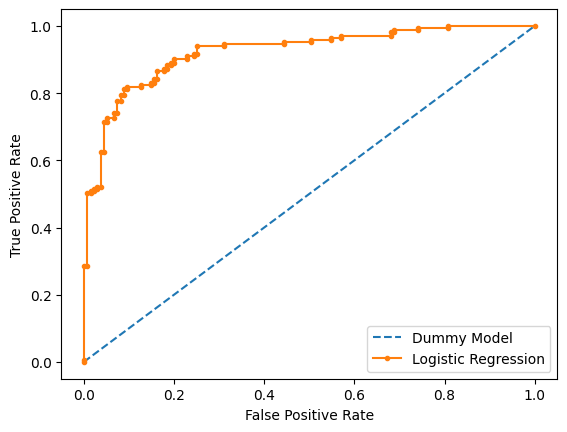

In [8]:
import matplotlib.pyplot as plt
plt.plot(fpr_dummy, tpr_dummy, linestyle='--', label='Dummy Model')
plt.plot(fpr_model, tpr_model, marker='.', label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

A model that "hugs" the top-left corner (high TPR, low FPR) is better; a diagonal line (dummy/random model) represents no predictive skill.

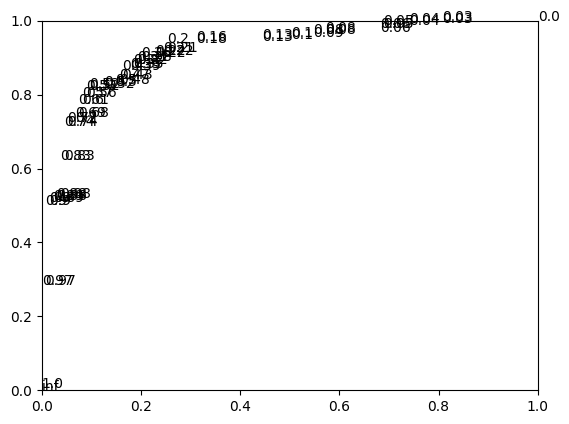

In [9]:
for i, (fpr_i, tpr_i, thresh) in enumerate(zip(fpr_model, tpr_model, thresholds)):
    plt.annotate(round(thresh, 2), (fpr_i, tpr_i))